# vadiation processing

크게 `data` , `training`, `result(prediction)` 순으로 진행  

# data

크게 3가지의 데이터를 처리 해서 사용  
* site : 데이터의 출처  
* save : 현재 저장된 데이터의 경로  

| data | from | 비고 | site | save |
|---|---|---|:---|:---|
| count(발생빈도) | DB | 2021년도 발생빈도만 처리해서 사용 |  |  |
| 날씨 데이터 | 기상청 사이트 | 강수, 강수형태, 기온, 습도, 풍속 사용 | https://data.kma.go.kr/data/rmt/rmtList.do?code=410&pgmNo=571 | http://202.31.200.194:8888/tree/NPLAB-NAS/Members/SEO/Emergency_Demand/load_weather_data/weather_data_2021 |
| 인구 데이터 | 춘천시 통계 |  | https://cityhall.chuncheon.go.kr/chstat/board/list.chuncheon?boardId=BBS_0000613&menuCd=DOM_000011106001000000&startPage=11 | http://202.31.200.194:8888/edit/NPLAB-NAS/Members/SEO/Emergency_Demand/sample_table/popl.xlsx |
| 휴일 데이터 | CSV file | save는 2021년 파일 , holiday2022.csv 파일에 validation용  |  | http://202.31.200.194:8888/edit/NPLAB-NAS/Members/SEO/Emergency_Demand/load_holiday_data/holiday.csv |

## data-count

In [2]:
%config Completer.use_jedi = False

In [3]:
# import package
import mariadb
import sys
import pandas as pd
import datetime
import itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'NanumGothic'


In [3]:
def get_csv(table_name, gugun='춘천시'):
    # DB에서 raw 데이터 가져오기 및 gugun으로 원하는 시도만 return
    try:
        conn = mariadb.connect(
        user = "root",
        password = "133nplab",
        host = "localhost",
        port = 3306,
        database = "TC"
        )
    except mariadb.Error as e:
        print(e)
        
    cur = conn.cursor()
    sql_query = "SELECT * from " + table_name
    cur.execute(sql_query)
    rows = cur.fetchall()
    table_query = "DESC " + table_name
    cur.execute(table_query)
    schema = cur.fetchall()
    columns = [name[0] for name in schema]
    recs = [rec for rec in rows]
    df = pd.DataFrame(recs,columns=columns)
    del rows
    return df[df['OCC_GUGUN_NM']== gugun]

raw_data = get_csv("tc_resact", '춘천시')
raw_data

,SEQ,DSR_SEQ,SEO_WARD_ID_NM,DSP_WARD_ID_NM,RES_REPORT_NO,CALL_DAY,CALL_TIME,DSP_DAY,DSP_TIME,LOC_ARV_DAY,...,RES_CNT,DTH_CNT,APLCT_CNT,GRID_S_CD,GRID_L_CD,STDG_CD,CLCT_STAT_CD,CLCT_DTIME,CLCT_SERIAL_NO,ROW_IDX
2,9869,IU4200620957,강원소방본부,(구)1항공대,20084200101R00034,20080728,1317,20080728,1411,20080728,...,0,0,0,None,None,None,C000,20211119183945,20211119183935,3
6,9873,IU4200623212,강원소방본부,(구)1항공대,20084200101R00036,20080730,1644,20080730,1647,20080730,...,0,0,0,None,None,None,C000,20211119183945,20211119183935,7
7,9874,IU4200621966,강원소방본부,(구)1항공대,20084200101R00035,20080729,1347,20080729,1459,20080729,...,0,0,0,None,None,None,C000,20211119183945,20211119183935,8
8,9875,IU4200615380,강원소방본부,(구)1항공대,20084200101R00033,20080722,1439,20080722,1500,20080722,...,0,0,0,None,None,None,C000,20211119183945,20211119183935,9
27,9894,IZ4200759580,강원소방본부,(구)1항공대,20084200101R00116,20081215,1515,20081215,1532,20081215,...,0,0,0,None,None,None,C000,20211119183945,20211119183935,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377101,702859,WP4207812028,춘천소방서,춘천119구조대,2022420120300370,20220228,004700,20220228,004700,20220228,...,0,0,0,None,라사2186,4211011200,C000,20220401004515,20220401004509,669815
377102,702860,WP4207812421,춘천소방서,춘천119구조대,2022420120300372,20220228,112600,20220228,112700,20220228,...,0,0,0,None,,,C000,20220401004515,20220401004509,669816
377103,702861,WP4207812758,춘천소방서,춘천119구조대,2022420120300373,20220228,161500,20220228,161700,20220228,...,0,0,0,None,라사2287,4211012000,C000,20220401004515,20220401004509,669817
377104,702862,WP4207812028,춘천소방서,효자119안전센터,2022420110300047,20220228,004700,20220228,004700,20220228,...,0,0,0,None,라사2186,4211011200,C000,20220401004515,20220401004509,669818


In [4]:
# resact function
import mariadb
import sys
import pandas as pd
import datetime
import itertools
import numpy as np
import matplotlib.pyplot as plt

    
def Format(time):
    # RAW 데이터에서 시간 포맷을 처리
    try:
        tmp = datetime.datetime.strptime(str(time),'%Y%m%d%H%M%f')
        d = datetime.date(tmp.year , tmp.month, tmp.day)
        t = datetime.time(tmp.hour, tmp.minute)
        return datetime.datetime.combine(d, t)
    except:
        tmp = datetime.datetime.strptime(str(time),'%Y-%m-%d %H%M%f')
        d = datetime.date(tmp.year , tmp.month, tmp.day)
        t = datetime.time(tmp.hour, tmp.minute)
        return datetime.datetime.combine(d, t)

def hourFormat(time):
    # Format 함수에서 시간대를 처리후에 1시간 단위로 변경해줌
    try:
        tmp = datetime.datetime.strptime(str(time),'%Y-%m-%d %H:%M:%f').replace(minute=0)
        return tmp
    except:
        tmp = datetime.datetime.strptime(str(time),'%Y%m%d%H%M%f').replace(minute=0)
        return tmp
    
    
adam = ['신북읍','동면','동산면','신동면','동내면','남면','남산면',
         '서면','사북면','북산면','소양동','교동','조운동','약사명동','근화동',
         '후평1동','후평2동','후평3동','효자1동','효자2동','효자3동','석사동','퇴계동','강남동','신사우동']

etc_h_dong = {'소양동' : ['소양로2가' , '소양로3가' , '소양로4가' , '봉의동' , '옥천동' , '요선동' , '낙원동' , '중앙로1가'],
              '신사우동' : ['사농동' , '신동' , '우두동'],
              '근화동' : ['소양로1가' ,'중도동'],
              '약사명동' : ['약사동' , '중앙로2가' , '중앙로3가' , '죽림동'],
              '조운동' : ['조양동' , '운교동'],
              '후평동' : ['후평1동' , '후평2동' , '후평3동'],
              '강남동' : ['삼천동' , '송암동' , '온의동' , '칠전동'],
              '효자1동' : ['효자동'],
              '효자2동' : ['효자동'],
              '효자3동' : ['효자동'],
              '후평1동' : ['후평동'],
              '후평2동' : ['후평동'],
              '후평3동' : ['후평동'],
             }
h_dong = ['신북읍', '동면', '동산면', '신동면', '동내면', '남면', '남산면', '서면', '사북면', '북산면', '소양동', '교동', '조운동', '약사명동', 
          '근화동', '후평1동', '후평2동', '후평3동', '효자1동', '효자2동', '효자3동', '석사동', '퇴계동', '강남동', '신사우동']

def nm_space(dong_nm):
    # RAW 데이터에서는 "남면" 이라고 저장되어있다면 다른 파일에서는 "남  면"으로 저장되어 있으므로 처리
    if len(dong_nm) == 2:
        return f'{dong_nm[0]}  {dong_nm[1]}'
    else:
        return dong_nm

    
def get_h_dong(dong_nm):
    if dong_nm in h_dong:
        return dong_nm
    else:
        for key in etc_h_dong.keys():
            if dong_nm in etc_h_dong[key]: 
                return key
        

# df에서 원하는 기간의 time line 생성
def df_count(start , end , df):
    '''
    start = Format(20211201000000)
    end   = Format(20211215000000)
    '''
    start = Format(start)
    end   = Format(end)

    time_line = pd.date_range(start=start, end=end , freq='1h')  
    in_time = df[df['REG_DTIME'].isin(time_line)]
    return in_time , time_line


In [5]:
# RAW 데이터 가져 온 이후에 데이터 처리
class processing_data():
    def __init__(self, gugun = '춘천시'):
        self.data = get_csv("tc_resact", gugun)
        # h_dong을 기준으로 하기 때문에 h_dong 데이터 생성 및 한글 처리
        self.data['h_dong'] = self.data['OCC_DONG_NM'].apply(lambda x : get_h_dong(x))
        self.data['h_dong'] = self.data['h_dong'].apply(lambda x : nm_space(x))
        # 날짜와 시간이 따로저장되어있기 때문에 이를 합쳐서 만들어줌
        for idx in self.data.index:
            self.data.loc[idx ,'REG_DTIME'] = self.data['DSP_DAY'].loc[idx] + self.data['DSP_TIME'].loc[idx]
        self.data['REG_DTIME'] = self.data['REG_DTIME'].apply(lambda x : hourFormat(x))
        # 필요한 columns만 가져옴
        self.data = self.data[['REG_DTIME' , 'ACT_DESC' , 'GUIDE', 'h_dong']]
        # 시간 순으로 데이터를 정렬
        self.data.sort_values(by = 'REG_DTIME', inplace = True)
        
        
    def select_time(self, start = 20210101000000, end = 20220301000000):
        # 원하는 시간대 2021년 ~ 2022년도의 time line 생성
        in_time , time_line = df_count(start, end , self.data )
        in_time.sort_values(by = 'REG_DTIME', inplace = True)
        return in_time , time_line
    
    def get_count(self):
        in_time, time_line = self.select_time()
        #time_line = pd.date_range('2021/01/01' , '2022/03/01', freq='1h')#.astype(str)
        h_dong_idx = in_time['h_dong'].unique()
        # 시간 * 공간 의 multi index 생성
        mulit_index = list(itertools.product(time_line , h_dong_idx))
        count_df = pd.DataFrame(columns = ['REG_DTIME' , 'h_dong' , 'count' , 'ACT_DESC' , 'GUIDE'])
        IDX = 0
        SUM = 0
        # mulit index를 사용해서 원하는 시간대의 지여에 접근에서 발생 빈도수를 가져옴
        for time , h_dong in mulit_index:
        
            df_idxs = (in_time['REG_DTIME'] == time) & (in_time['h_dong'] == h_dong)
            if sum(df_idxs) == 0:
                count_df.loc[IDX] = [time , h_dong ,sum(df_idxs) , None , None]
            else:
                count_df.loc[IDX] = [time , h_dong ,sum(df_idxs) , list(in_time[df_idxs]['ACT_DESC']) , list(in_time[df_idxs]['GUIDE'])]
                SUM += sum(df_idxs)
                print(f'\n ---------- {time} : {h_dong}   {SUM} ---------- \n')
            IDX += 1
        
        return count_df

            
    def get_resact(self, path = 'resact_count.csv'):
        # 저장된 파일 불러오기
        df =  pd.read_csv(path)
        count_df = df[['REG_DTIME', 'h_dong' , 'count']]        
        self.count_df = count_df 
        return count_df
    
    def orgnal_count_plot(self , year):
        # 저장된 파일이 제대로 되었는지 확인 
        df = self.get_resact()
        dongs = df['h_dong'].unique()
        year_s = f'{year}/1/1/00'
        year_e = f'{year+1}/1/1/00'
        dt = pd.date_range(year_s ,year_e, freq='h')[:-1]        
        year_df = df[df['REG_DTIME'].isin(dt.astype(str))]
        f , axes = plt.subplots(21,1 , figsize=(20,66))
        x = range(len(year_df[year_df['h_dong'] == '강남동']['count']))
        for i,dong_nm in enumerate(df['h_dong'].unique()):
            year_dong_df = year_df[year_df['h_dong'] == dong_nm]['count']
            rat = len(year_dong_df[year_dong_df > 0]) / len(year_dong_df)
            axes[i].set_title(f'{dong_nm} count in {year} , ratio : {rat:.4f}')
            axes[i].scatter(x,year_dong_df , s=1)
        plt.show()



In [6]:
# 구조시간, 구조 내용 , 행정동별로 DataFrame 생성
# 이상태로는 학습을 돌리기에는 시간대별로 몇 건의 사건이 발생했는지 알기 힘드므로 처리가 필요함 
pdata  = processing_data()
pdata.data

,REG_DTIME,ACT_DESC,GUIDE,h_dong
7022,2008-01-29 12:00:00.000,"접보즉시 출동하여 현장 인명검색 실시한 바 요구조자 없었으며 화재완전진화 후 인원,...","인원, 장비 이상없이 귀대함",동산면
831,2008-02-01 10:00:00.200,요구조자가 수도계량기 확인을 위해 작업 중 계량기가 설치된 좁은 공간에 거꾸로 끼인...,None,후평1동
1259,2008-02-01 11:00:00.700,"상기장소 도로상에 화물트럭이 도로 옆 전봇대를 들이받은 사고로 현장확인한 바, 운전...",요구조자 후평구급대 인계하여 병원이송조치 및 현장상황 경찰(사북파출소 유희영 경사 ...,사북면
1374,2008-02-01 23:00:00.900,상기장소에서 마티즈(50나1034) 승용차량이 도로 연석을 들이받은 사고로 현장확인...,요구조자 후평구급대에 인계하여 병원이송조치 및 현장상황 경찰(후평지구대 김계현 경사...,후평1동
433,2008-02-02 11:00:00.300,우사로 현장도착시 최성기 상태로 인명검색 실시한바 요구조자 발생하지 않아 화재진압 ...,인명검색 및 화재진압보조,신북읍
...,...,...,...,...
377100,2022-02-28 10:00:00.000,- 고양이가 지붕위로 올라가서 못내려오고있다는 신고로 출동. - 현장도착하여 동물...,None,신북읍
377102,2022-02-28 11:00:00.000,차량화재 신고로 출동중 아스팔트 녹이는 중이며 선착한 펌프에서 진압 가능하다하여 지...,None,신사우동
377099,2022-02-28 16:00:00.000,[고양이 구조] 고양이가 본인 집 하수구에 끼어 못나온다는 신고. 구조대 현장 도...,배수구 뚜껑 개방,신동면
377103,2022-02-28 16:00:00.000,[위치추척] 아내 자살기도 추정 위치추적 출동. 출동 중 신북구급 출동으로 구조대...,출동 중 귀소.,후평1동


In [7]:
pdata  = processing_data()
count_df = pdata.get_count()
count_df.to_csv('resact_2021.csv',index=False)

<ipython-input-5-9324302d5803>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  in_time.sort_values(by = 'REG_DTIME', inplace = True)



 ---------- 2021-01-01 07:00:00 : 동  면   1 ---------- 


 ---------- 2021-01-01 12:00:00 : 퇴계동   3 ---------- 


 ---------- 2021-01-01 18:00:00 : 효자1동   5 ---------- 


 ---------- 2021-01-01 21:00:00 : 퇴계동   8 ---------- 


 ---------- 2021-01-01 22:00:00 : 효자1동   9 ---------- 


 ---------- 2021-01-02 08:00:00 : 신사우동   11 ---------- 


 ---------- 2021-01-02 08:00:00 : 강남동   12 ---------- 


 ---------- 2021-01-02 11:00:00 : 동산면   13 ---------- 


 ---------- 2021-01-02 13:00:00 : 동산면   14 ---------- 


 ---------- 2021-01-03 00:00:00 : 동  면   17 ---------- 


 ---------- 2021-01-03 04:00:00 : 효자1동   20 ---------- 


 ---------- 2021-01-03 11:00:00 : 석사동   21 ---------- 


 ---------- 2021-01-03 12:00:00 : 퇴계동   22 ---------- 


 ---------- 2021-01-03 12:00:00 : 동내면   24 ---------- 


 ---------- 2021-01-03 14:00:00 : 석사동   26 ---------- 


 ---------- 2021-01-03 20:00:00 : 퇴계동   28 ---------- 


 ---------- 2021-01-04 10:00:00 : 신북읍   29 ---------- 


 ---------- 2021-01-04 13:00:


 ---------- 2021-01-20 20:00:00 : 석사동   234 ---------- 


 ---------- 2021-01-20 21:00:00 : 퇴계동   235 ---------- 


 ---------- 2021-01-20 22:00:00 : 서  면   236 ---------- 


 ---------- 2021-01-21 00:00:00 : 퇴계동   237 ---------- 


 ---------- 2021-01-21 00:00:00 : 석사동   238 ---------- 


 ---------- 2021-01-21 10:00:00 : 신북읍   240 ---------- 


 ---------- 2021-01-21 14:00:00 : 효자1동   244 ---------- 


 ---------- 2021-01-21 14:00:00 : 소양동   245 ---------- 


 ---------- 2021-01-21 15:00:00 : 후평1동   246 ---------- 


 ---------- 2021-01-21 17:00:00 : 동  면   247 ---------- 


 ---------- 2021-01-21 21:00:00 : 동  면   250 ---------- 


 ---------- 2021-01-22 05:00:00 : 후평1동   251 ---------- 


 ---------- 2021-01-22 07:00:00 : 석사동   252 ---------- 


 ---------- 2021-01-22 11:00:00 : 신동면   256 ---------- 


 ---------- 2021-01-22 20:00:00 : 신동면   257 ---------- 


 ---------- 2021-01-23 21:00:00 : 퇴계동   260 ---------- 


 ---------- 2021-01-24 08:00:00 : 후평1동   261 ---------- 


 -----


 ---------- 2021-02-14 13:00:00 : 후평1동   472 ---------- 


 ---------- 2021-02-14 14:00:00 : 근화동   474 ---------- 


 ---------- 2021-02-14 21:00:00 : 조운동   475 ---------- 


 ---------- 2021-02-14 22:00:00 : 신사우동   476 ---------- 


 ---------- 2021-02-14 23:00:00 : 효자1동   478 ---------- 


 ---------- 2021-02-15 03:00:00 : 신사우동   479 ---------- 


 ---------- 2021-02-15 13:00:00 : 신북읍   481 ---------- 


 ---------- 2021-02-15 15:00:00 : 퇴계동   484 ---------- 


 ---------- 2021-02-15 17:00:00 : 후평1동   485 ---------- 


 ---------- 2021-02-16 00:00:00 : 교  동   486 ---------- 


 ---------- 2021-02-16 15:00:00 : 퇴계동   489 ---------- 


 ---------- 2021-02-16 17:00:00 : 동내면   490 ---------- 


 ---------- 2021-02-16 17:00:00 : 사북면   491 ---------- 


 ---------- 2021-02-16 18:00:00 : 사북면   492 ---------- 


 ---------- 2021-02-16 23:00:00 : 석사동   493 ---------- 


 ---------- 2021-02-16 23:00:00 : 후평1동   494 ---------- 


 ---------- 2021-02-17 09:00:00 : 석사동   496 ---------- 


 -----


 ---------- 2021-03-03 18:00:00 : 동  면   707 ---------- 


 ---------- 2021-03-04 05:00:00 : 동산면   708 ---------- 


 ---------- 2021-03-04 07:00:00 : 동산면   709 ---------- 


 ---------- 2021-03-04 09:00:00 : 후평1동   711 ---------- 


 ---------- 2021-03-04 13:00:00 : 신북읍   712 ---------- 


 ---------- 2021-03-04 14:00:00 : 동내면   713 ---------- 


 ---------- 2021-03-04 20:00:00 : 후평1동   715 ---------- 


 ---------- 2021-03-04 21:00:00 : 퇴계동   716 ---------- 


 ---------- 2021-03-05 08:00:00 : 교  동   719 ---------- 


 ---------- 2021-03-05 09:00:00 : 서  면   720 ---------- 


 ---------- 2021-03-05 10:00:00 : 퇴계동   723 ---------- 


 ---------- 2021-03-05 13:00:00 : 신북읍   724 ---------- 


 ---------- 2021-03-05 17:00:00 : 조운동   727 ---------- 


 ---------- 2021-03-06 07:00:00 : 신북읍   729 ---------- 


 ---------- 2021-03-06 16:00:00 : 석사동   730 ---------- 


 ---------- 2021-03-06 17:00:00 : 후평1동   731 ---------- 


 ---------- 2021-03-06 20:00:00 : 석사동   732 ---------- 


 ------

...


 ---------- 2021-12-14 00:00:00 : 강남동   5467 ---------- 


 ---------- 2021-12-14 06:00:00 : 약사명동   5468 ---------- 


 ---------- 2021-12-14 09:00:00 : 동산면   5469 ---------- 


 ---------- 2021-12-14 10:00:00 : 신북읍   5470 ---------- 


 ---------- 2021-12-14 11:00:00 : 후평1동   5471 ---------- 


 ---------- 2021-12-14 11:00:00 : 조운동   5473 ---------- 


 ---------- 2021-12-14 12:00:00 : 퇴계동   5476 ---------- 


 ---------- 2021-12-14 13:00:00 : 퇴계동   5477 ---------- 


 ---------- 2021-12-14 13:00:00 : 서  면   5479 ---------- 


 ---------- 2021-12-14 14:00:00 : 동내면   5481 ---------- 


 ---------- 2021-12-14 15:00:00 : 동내면   5482 ---------- 


 ---------- 2021-12-14 16:00:00 : 동산면   5483 ---------- 


 ---------- 2021-12-14 17:00:00 : 신동면   5485 ---------- 


 ---------- 2021-12-14 19:00:00 : 동내면   5486 ---------- 


 ---------- 2021-12-14 21:00:00 : 퇴계동   5487 ---------- 


 ---------- 2021-12-15 07:00:00 : 효자1동   5488 ---------- 


 ---------- 2021-12-15 11:00:00 : 강남동   5489 ------


 ---------- 2021-12-28 09:00:00 : 퇴계동   5642 ---------- 


 ---------- 2021-12-28 10:00:00 : 석사동   5643 ---------- 


 ---------- 2021-12-28 13:00:00 : 효자1동   5645 ---------- 


 ---------- 2021-12-28 13:00:00 : 서  면   5646 ---------- 


 ---------- 2021-12-28 15:00:00 : 남산면   5648 ---------- 


 ---------- 2021-12-28 16:00:00 : 퇴계동   5651 ---------- 


 ---------- 2021-12-28 16:00:00 : 교  동   5652 ---------- 


 ---------- 2021-12-28 18:00:00 : 동  면   5653 ---------- 


 ---------- 2021-12-28 18:00:00 : 강남동   5654 ---------- 


 ---------- 2021-12-28 18:00:00 : 남산면   5656 ---------- 


 ---------- 2021-12-28 19:00:00 : 동내면   5658 ---------- 


 ---------- 2021-12-28 19:00:00 : 서  면   5659 ---------- 


 ---------- 2021-12-28 22:00:00 : 후평1동   5660 ---------- 


 ---------- 2021-12-28 23:00:00 : 효자1동   5662 ---------- 


 ---------- 2021-12-28 23:00:00 : 조운동   5663 ---------- 


 ---------- 2021-12-29 00:00:00 : 소양동   5665 ---------- 


 ---------- 2021-12-29 02:00:00 : 퇴계동   5666 ---


 ---------- 2022-01-09 13:00:00 : 신사우동   5828 ---------- 


 ---------- 2022-01-09 16:00:00 : 후평1동   5829 ---------- 


 ---------- 2022-01-09 21:00:00 : 신동면   5830 ---------- 


 ---------- 2022-01-10 10:00:00 : 서  면   5831 ---------- 


 ---------- 2022-01-10 11:00:00 : 동내면   5832 ---------- 


 ---------- 2022-01-10 14:00:00 : 후평1동   5833 ---------- 


 ---------- 2022-01-10 14:00:00 : 소양동   5834 ---------- 


 ---------- 2022-01-10 15:00:00 : 강남동   5835 ---------- 


 ---------- 2022-01-10 18:00:00 : 동내면   5836 ---------- 


 ---------- 2022-01-10 18:00:00 : 소양동   5837 ---------- 


 ---------- 2022-01-10 19:00:00 : 후평1동   5839 ---------- 


 ---------- 2022-01-10 20:00:00 : 퇴계동   5841 ---------- 


 ---------- 2022-01-10 20:00:00 : 후평1동   5842 ---------- 


 ---------- 2022-01-10 22:00:00 : 후평1동   5843 ---------- 


 ---------- 2022-01-10 22:00:00 : 근화동   5845 ---------- 


 ---------- 2022-01-11 01:00:00 : 강남동   5846 ---------- 


 ---------- 2022-01-11 03:00:00 : 소양동   5847 ---


 ---------- 2022-01-24 21:00:00 : 퇴계동   6003 ---------- 


 ---------- 2022-01-25 02:00:00 : 석사동   6005 ---------- 


 ---------- 2022-01-25 05:00:00 : 근화동   6007 ---------- 


 ---------- 2022-01-25 10:00:00 : 동  면   6008 ---------- 


 ---------- 2022-01-25 11:00:00 : 동내면   6010 ---------- 


 ---------- 2022-01-25 12:00:00 : 퇴계동   6011 ---------- 


 ---------- 2022-01-25 14:00:00 : 남산면   6012 ---------- 


 ---------- 2022-01-25 15:00:00 : 후평1동   6014 ---------- 


 ---------- 2022-01-25 16:00:00 : 신북읍   6015 ---------- 


 ---------- 2022-01-25 18:00:00 : 서  면   6017 ---------- 


 ---------- 2022-01-25 18:00:00 : 근화동   6019 ---------- 


 ---------- 2022-01-25 20:00:00 : 남  면   6020 ---------- 


 ---------- 2022-01-25 21:00:00 : 효자1동   6022 ---------- 


 ---------- 2022-01-25 23:00:00 : 효자1동   6024 ---------- 


 ---------- 2022-01-26 01:00:00 : 퇴계동   6025 ---------- 


 ---------- 2022-01-26 01:00:00 : 효자1동   6026 ---------- 


 ---------- 2022-01-26 02:00:00 : 서  면   6027 --


 ---------- 2022-02-12 12:00:00 : 석사동   6206 ---------- 


 ---------- 2022-02-12 13:00:00 : 동  면   6207 ---------- 


 ---------- 2022-02-12 14:00:00 : 후평1동   6208 ---------- 


 ---------- 2022-02-12 15:00:00 : 효자1동   6209 ---------- 


 ---------- 2022-02-12 17:00:00 : 석사동   6210 ---------- 


 ---------- 2022-02-12 21:00:00 : 신북읍   6211 ---------- 


 ---------- 2022-02-13 09:00:00 : 교  동   6212 ---------- 


 ---------- 2022-02-13 11:00:00 : 동산면   6213 ---------- 


 ---------- 2022-02-13 15:00:00 : 후평1동   6214 ---------- 


 ---------- 2022-02-13 19:00:00 : 퇴계동   6215 ---------- 


 ---------- 2022-02-13 19:00:00 : 신사우동   6216 ---------- 


 ---------- 2022-02-13 23:00:00 : 퇴계동   6218 ---------- 


 ---------- 2022-02-14 05:00:00 : 신사우동   6219 ---------- 


 ---------- 2022-02-14 10:00:00 : 근화동   6220 ---------- 


 ---------- 2022-02-14 12:00:00 : 효자1동   6221 ---------- 


 ---------- 2022-02-14 14:00:00 : 퇴계동   6225 ---------- 


 ---------- 2022-02-14 17:00:00 : 조운동   6226 --

## data-weather
> notebook : http://202.31.200.194:8888/notebooks/NPLAB-NAS/Members/SEO/Emergency_Demand/load_weather_data/Weather_preprocessing.ipynb

weather 파일이 여러 개여서 다른 위치에서 처리  
> 여기에 결과 파일 저장 : http://202.31.200.194:8888/edit/NPLAB-NAS/Members/SEO/Emergency_Demand/load_weather_data/total_weather_2021.csv

In [8]:
pd.read_csv('./load_weather_data/total_weather_2021.csv')

,Unnamed: 0,datetime,windspd,humid,temp,precip_form,precip,h_dong
0,0,2021-01-01 00:00:00,0.8,57.0,-7.6,0.0,0.0,강남동
1,1,2021-01-01 01:00:00,0.7,43.0,-4.7,0.0,0.0,강남동
2,2,2021-01-01 02:00:00,2.2,39.0,-2.0,0.0,0.0,강남동
3,3,2021-01-01 03:00:00,2.1,37.0,-0.1,0.0,0.0,강남동
4,4,2021-01-01 04:00:00,3.4,37.0,0.7,0.0,0.0,강남동
...,...,...,...,...,...,...,...,...
218995,8755,2021-12-31 19:00:00,0.3,73.0,-13.6,0.0,0.0,북산면
218996,8756,2021-12-31 20:00:00,0.0,78.0,-14.3,0.0,0.0,북산면
218997,8757,2021-12-31 21:00:00,0.4,77.0,-14.0,0.0,0.0,북산면
218998,8758,2021-12-31 22:00:00,0.3,78.0,-13.4,0.0,0.0,북산면


## data - holiday
> notebook : http://202.31.200.194:8888/notebooks/NPLAB-NAS/Members/SEO/Emergency_Demand/load_holiday_data/Holiday_preprocessing.ipynb

> result holiday : http://202.31.200.194:8888/edit/NPLAB-NAS/Members/SEO/Emergency_Demand/load_holiday_data/result/result.csv

In [9]:
pd.read_csv('./load_holiday_data/result/holiday_2021.csv')

,REG_DTIME,h_dong,isHoliday
0,2021-01-01 00:00:00,동 면,True
1,2021-01-01 00:00:00,퇴계동,True
2,2021-01-01 00:00:00,효자1동,True
3,2021-01-01 00:00:00,신사우동,True
4,2021-01-01 00:00:00,강남동,True
...,...,...,...
213712,2022-03-01 00:00:00,남산면,False
213713,2022-03-01 00:00:00,근화동,False
213714,2022-03-01 00:00:00,교 동,False
213715,2022-03-01 00:00:00,신동면,False


## data-pops

> notebook : http://202.31.200.194:8888/notebooks/NPLAB-NAS/Members/SEO/Emergency_Demand/data/popl.ipynb


> result : http://202.31.200.194:8888/edit/NPLAB-NAS/Members/SEO/Emergency_Demand/data/popl_2021.csv

In [10]:
pd.read_csv('./data/popl_2021.csv')

,REG_DTIME,h_dong,month,pops
0,2021-01-01 00:00:00,신북읍,2021.1,7694.0
1,2021-01-01 00:00:00,동 면,2021.1,19670.0
2,2021-01-01 00:00:00,동산면,2021.1,1478.0
3,2021-01-01 00:00:00,신동면,2021.1,2575.0
4,2021-01-01 00:00:00,동내면,2021.1,17313.0
...,...,...,...,...
219020,2022-01-01 00:00:00,효자3동,2022.1,4362.0
219021,2022-01-01 00:00:00,석사동,2022.1,34593.0
219022,2022-01-01 00:00:00,퇴계동,2022.1,48812.0
219023,2022-01-01 00:00:00,강남동,2022.1,22607.0


## data-megre

#### train data

In [19]:
# read data
count = pd.read_csv('./resact_2021.csv')
count = count[['REG_DTIME' , 'h_dong' , 'count']]
weather = pd.read_csv('./load_weather_data/total_weather_2021.csv')
hoilday = pd.read_csv('./load_holiday_data/result/holiday_2021.csv')
pops = pd.read_csv('./data/popl_2021.csv')

In [20]:
# DataFrame column명 통일 및 dtype 통일
weather.rename(columns ={'datetime' : 'REG_DTIME'} , inplace=True)
hoilday.rename(columns ={'date' : 'REG_DTIME'} , inplace=True)
count['REG_DTIME'] = count['REG_DTIME'].astype(str)
weather['REG_DTIME'] = weather['REG_DTIME'].astype(str)
hoilday['REG_DTIME'] = hoilday['REG_DTIME'].astype(str)

In [21]:
# train_data 생성(2021년도 ~ 2022년)
m_df = pd.merge(count, weather , how='inner' , on = ['REG_DTIME','h_dong'])
m_df = pd.merge(m_df, pops , how='inner' , on = ['REG_DTIME','h_dong'])
m_df = pd.merge(m_df, hoilday , how='inner' , on = ['REG_DTIME' , 'h_dong'])
m_df = m_df.drop_duplicates(subset=None, keep='first', inplace=False, ignore_index=False)
m_df.to_csv('train.csv', index=False)
# 24(하루) * 365(요일) * 21(전체 동 갯수) = 183960 
m_df

,REG_DTIME,h_dong,count,Unnamed: 0,windspd,humid,temp,precip_form,precip,month,pops,isHoliday
0,2021-01-01 00:00:00,동 면,0,0,0.8,57.0,-7.6,0.0,0.0,2021.10,19670.0,True
1,2021-01-01 00:00:00,퇴계동,0,0,0.8,57.0,-7.6,0.0,0.0,2021.10,49431.0,True
2,2021-01-01 00:00:00,효자1동,0,0,0.8,57.0,-7.6,0.0,0.0,2021.10,4560.0,True
3,2021-01-01 00:00:00,신사우동,0,0,0.8,57.0,-7.6,0.0,0.0,2021.10,21857.0,True
4,2021-01-01 00:00:00,강남동,0,0,0.8,57.0,-7.6,0.0,0.0,2021.10,19089.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...
183955,2021-12-31 23:00:00,남산면,0,8759,0.6,69.0,-13.3,0.0,0.0,2021.12,3424.0,False
183956,2021-12-31 23:00:00,근화동,0,8759,0.7,72.0,-12.4,0.0,0.0,2021.12,8540.0,False
183957,2021-12-31 23:00:00,교 동,0,8759,0.7,72.0,-12.4,0.0,0.0,2021.12,3549.0,False
183958,2021-12-31 23:00:00,신동면,0,8759,0.6,69.0,-13.3,0.0,0.0,2021.12,2578.0,False


#### test data
기존에 생성된 데이터로 사용

In [22]:
# read data
count = pd.read_csv('./data/test/count.csv')
count = count[['REG_DTIME' , 'h_dong' , 'count']]
weather = pd.read_csv('./data/test/weather.csv')
hoilday = pd.read_csv('./data/test/holiday.csv')
pops = pd.read_csv('./data/test/pops.csv')

In [23]:
# DataFrame column명 통일 및 dtype 통일
weather.rename(columns ={'datetime' : 'REG_DTIME'} , inplace=True)
hoilday.rename(columns ={'date' : 'REG_DTIME'} , inplace=True)
count['REG_DTIME'] = count['REG_DTIME'].astype(str)
weather['REG_DTIME'] = weather['REG_DTIME'].astype(str)
hoilday['REG_DTIME'] = hoilday['REG_DTIME'].astype(str)

In [24]:
# test_data 생성(2022년도 1월 ~ 2022년 2월)
m_df = pd.merge(count, weather , how='inner' , on = ['REG_DTIME','h_dong'])
m_df = pd.merge(m_df, pops , how='inner' , on = ['REG_DTIME','h_dong'])
m_df = pd.merge(m_df, hoilday , how='inner' , on = ['REG_DTIME'])
m_df = m_df.drop_duplicates(subset=None, keep='first', inplace=False, ignore_index=False)
m_df.to_csv('test.csv',index=False)

In [25]:
m_df

,REG_DTIME,h_dong,count,Unnamed: 0_x,windspd,humid,temp,precip_form,precip,Unnamed: 0_y,month,pops,isHoliday
0,2022-01-01 00:00:00,석사동,0,0,1.4,60.0,-9.7,0.0,0.0,21,1,34593.0,True
21,2022-01-01 00:00:00,신동면,0,0,0.3,48.0,-8.6,0.0,0.0,3,1,2602.0,True
42,2022-01-01 00:00:00,강남동,0,0,1.4,60.0,-9.7,0.0,0.0,23,1,22607.0,True
63,2022-01-01 00:00:00,서 면,0,0,1.4,60.0,-9.7,0.0,0.0,7,1,3782.0,True
84,2022-01-01 00:00:00,남 면,0,0,0.3,48.0,-8.6,0.0,0.0,5,1,1073.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
613767,2022-02-27 23:00:00,퇴계동,0,1391,0.7,80.0,0.8,0.0,0.0,34797,2,48681.0,False
613788,2022-02-27 23:00:00,북산면,0,1391,0.0,84.0,2.6,0.0,0.0,34784,2,965.0,False
613809,2022-02-27 23:00:00,조운동,0,1391,0.7,80.0,0.8,0.0,0.0,34787,2,2675.0,False
613830,2022-02-27 23:00:00,동산면,0,1391,0.5,89.0,1.6,0.0,0.0,34777,2,1445.0,False


In [17]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')


In [27]:
train

,REG_DTIME,h_dong,count,Unnamed: 0,windspd,humid,temp,precip_form,precip,month,pops,isHoliday
0,2021-01-01 00:00:00,동 면,0,0,0.8,57.0,-7.6,0.0,0.0,2021.10,19670.0,True
1,2021-01-01 00:00:00,퇴계동,0,0,0.8,57.0,-7.6,0.0,0.0,2021.10,49431.0,True
2,2021-01-01 00:00:00,효자1동,0,0,0.8,57.0,-7.6,0.0,0.0,2021.10,4560.0,True
3,2021-01-01 00:00:00,신사우동,0,0,0.8,57.0,-7.6,0.0,0.0,2021.10,21857.0,True
4,2021-01-01 00:00:00,강남동,0,0,0.8,57.0,-7.6,0.0,0.0,2021.10,19089.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...
183955,2021-12-31 23:00:00,남산면,0,8759,0.6,69.0,-13.3,0.0,0.0,2021.12,3424.0,False
183956,2021-12-31 23:00:00,근화동,0,8759,0.7,72.0,-12.4,0.0,0.0,2021.12,8540.0,False
183957,2021-12-31 23:00:00,교 동,0,8759,0.7,72.0,-12.4,0.0,0.0,2021.12,3549.0,False
183958,2021-12-31 23:00:00,신동면,0,8759,0.6,69.0,-13.3,0.0,0.0,2021.12,2578.0,False


## data - ewma & training data

ewma 적용 및 , trainer에 넣을 데이터로 변경
ewma는 alpha만 사용


In [4]:
def moving_average_alpha(df: pd.DataFrame, unit: float):
    '''
    training datset에 ewma를 적용하는 함수 , unit = 0.3 or 0.4
    '''
    ret_df = pd.DataFrame()
    max_value = df['count'].max()
    # forward df
    for dong in df['h_dong'].unique():
        dong_df = df[df['h_dong'] == dong]
        inv_dong_df = df[df['h_dong'] == dong][::-1]
        dong_df['count'] = dong_df['count'].ewm(alpha = unit).mean()
        for_ewma = dong_df['count'].ewm(alpha = unit).mean()
        back_ewma = inv_dong_df['count'].ewm(alpha = unit).mean()

        ewma = (for_ewma + back_ewma)/2 
        df['count'][dong_df.index] = ewma 
    df['count'] = df['count']  /  df['count'].max() * (max_value)
    
    #print(max_value , df['count'].max())
    return df

def data_processing(path : str  , unit : float):
    # path  : 데이터가 저장된 경로
    # unit  : ewma의 unit
    
    data = pd.read_csv(path)    
    # 사용하는 column만 선택
    data = data[['REG_DTIME', 'h_dong', 'count', 'pops', 'windspd','humid', 'temp', 'precip_form', 'precip', 'isHoliday']]
    data['REG_DTIME'] = pd.to_datetime(data['REG_DTIME'])
    data['DOW'] = data['REG_DTIME'].dt.dayofweek
    data['HOD'] = data['REG_DTIME'].dt.hour
    data['MOY'] = data['REG_DTIME'].dt.month
    # time_idx 시간을 고유하게 표현(윤년)
    #for x , y in enumerate(data['REG_DTIME'].unique()):
    #    t_data_index = data[data['REG_DTIME'] == y].index
    #    data.loc[t_data_index , 'time_idx'] = x
    data["time_idx"] =  \
    data["REG_DTIME"].dt.year * 365*24 + \
    data["REG_DTIME"].dt.day_of_year * 24  + \
    data["REG_DTIME"].dt.hour 
    data["time_idx"] -= data["time_idx"].min()
    # trainer에 넣기 위해서 category로 만들기
    data['h_dong'] = data['h_dong'].astype(str)
    data['DOW'] = data['DOW'].astype(str)
    data['HOD'] = data['HOD'].astype(str)
    data['MOY'] = data['MOY'].astype(str)
    data['precip_form'] = data['precip_form'].astype(str)
    data['isHoliday'] = data['isHoliday'].astype(str)
    # ewma 적용
    if unit == 0:
        return data
    else:
        data = moving_average_alpha(data,unit)
        return data


In [5]:
# 학습에 필요한 데이터 생성 완료
data = data_processing('train.csv' , 0.4)
data

<ipython-input-4-ff4da8c2a335>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dong_df['count'] = dong_df['count'].ewm(alpha = unit).mean()
<ipython-input-4-ff4da8c2a335>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['count'][dong_df.index] = ewma
<ipython-input-4-ff4da8c2a335>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-ver

<ipython-input-4-ff4da8c2a335>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dong_df['count'] = dong_df['count'].ewm(alpha = unit).mean()
<ipython-input-4-ff4da8c2a335>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['count'][dong_df.index] = ewma
<ipython-input-4-ff4da8c2a335>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-ver

,REG_DTIME,h_dong,count,pops,windspd,humid,temp,precip_form,precip,isHoliday,DOW,HOD,MOY,time_idx
0,2021-01-01 00:00:00,동 면,1.566806e-02,19670.0,0.8,57.0,-7.6,0.0,0.0,True,4,0,1,0
1,2021-01-01 00:00:00,퇴계동,2.473531e-03,49431.0,0.8,57.0,-7.6,0.0,0.0,True,4,0,1,0
2,2021-01-01 00:00:00,효자1동,1.210534e-04,4560.0,0.8,57.0,-7.6,0.0,0.0,True,4,0,1,0
3,2021-01-01 00:00:00,신사우동,8.908949e-08,21857.0,0.8,57.0,-7.6,0.0,0.0,True,4,0,1,0
4,2021-01-01 00:00:00,강남동,4.454475e-08,19089.0,0.8,57.0,-7.6,0.0,0.0,True,4,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183955,2021-12-31 23:00:00,남산면,1.685779e-03,3424.0,0.6,69.0,-13.3,0.0,0.0,False,4,23,12,8759
183956,2021-12-31 23:00:00,근화동,3.284202e-20,8540.0,0.7,72.0,-12.4,0.0,0.0,False,4,23,12,8759
183957,2021-12-31 23:00:00,교 동,5.335122e-17,3549.0,0.7,72.0,-12.4,0.0,0.0,False,4,23,12,8759
183958,2021-12-31 23:00:00,신동면,5.879906e-07,2578.0,0.6,69.0,-13.3,0.0,0.0,False,4,23,12,8759


# training

training 생성 , tft network 생성 , train 

##  training - trainer

In [6]:
# 학습에 필요한 package load
import os
#os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import copy
import warnings
import torch
import optuna
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger


from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet , EncoderNormalizer , GroupNormalizer
from pytorch_forecasting.metrics import SMAPE, PoissonLoss, QuantileLoss
#from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

#import tensorflow as tf 
import tensorboard as tb 
#tf.io.gfile = tb.compat.tensorflow_stub.io.gfile

import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings("ignore")  # avoid printing out absolute paths
plt.rcParams['font.family'] = 'NanumGothic'
#plt.rcParams['font.sans-serif'] = ['NanumGothic.ttf', 'sans-serif']

/home/nplab/.local/lib/python3.8/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /home/nplab/.local/lib/python3.8/site-packages/torchvision/image.so: undefined symbol: _ZN2at4_ops19empty_memory_format4callEN3c108ArrayRefIlEENS2_8optionalINS2_10ScalarTypeEEENS5_INS2_6LayoutEEENS5_INS2_6DeviceEEENS5_IbEENS5_INS2_12MemoryFormatEEE
  warn(f"Failed to load image Python extension: {e}")
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.1.36ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will n

In [7]:
def get_training(data , max_prediction_length = 24 , max_encoder_length = 24*7):
    # traing data 생성
    training_cutoff = data["time_idx"].max() - max_prediction_length
    training = TimeSeriesDataSet(
        data[lambda x : x.time_idx <= training_cutoff],
        time_idx = "time_idx",
        target = "count",
        group_ids = ['h_dong'],
        min_encoder_length=max_encoder_length // 2,  # keep encoder length long (as it is in the validation set)
        max_encoder_length=max_encoder_length,
        min_prediction_length=1,
        max_prediction_length=24,
        static_categoricals=["h_dong"],
        time_varying_known_categoricals=["HOD", "DOW" , 'isHoliday', 'MOY'],
        time_varying_known_reals=['pops'],
        time_varying_unknown_categoricals=['precip_form'],
        time_varying_unknown_reals=['count','windspd' , 'temp' ,'precip'], 
        target_normalizer=GroupNormalizer(
            groups=["h_dong"], 
            transformation="relu",
            center = False
        ),
        add_relative_time_idx=True,
        add_target_scales=False,
        add_encoder_length=True,
        #allow_missing=True,
        allow_missing_timesteps = True,
        #predict_mode = False
        )
    return training

In [8]:
training = get_training(data,24, 24*7)

In [18]:
training

TimeSeriesDataSet[length=183939](
	time_idx='time_idx',
	target='count',
	group_ids=['h_dong'],
	weight=None,
	max_encoder_length=168,
	min_encoder_length=84,
	min_prediction_idx=0,
	min_prediction_length=1,
	max_prediction_length=24,
	static_categoricals=['h_dong'],
	static_reals=['encoder_length'],
	time_varying_known_categoricals=['HOD', 'DOW', 'isHoliday', 'MOY'],
	time_varying_known_reals=['pops', 'relative_time_idx'],
	time_varying_unknown_categoricals=['precip_form'],
	time_varying_unknown_reals=['count', 'windspd', 'temp', 'precip'],
	variable_groups={},
	constant_fill_strategy={},
	allow_missing_timesteps=True,
	lags={},
	add_relative_time_idx=True,
	add_target_scales=False,
	add_encoder_length=True,
	target_normalizer=GroupNormalizer(
	method='standard',
	groups=['h_dong'],
	center=False,
	scale_by_group=False,
	transformation='relu',
	method_kwargs={}
),
	categorical_encoders={'__group_id__h_dong': NaNLabelEncoder(add_nan=False, warn=True), 'h_dong': NaNLabelEncoder(add_nan=

In [19]:
# dataloader 만들기
batch_size=32
dataloader = training.to_dataloader(batch_size)
validation = TimeSeriesDataSet.from_dataset(training, data, predict=True, stop_randomization=True)
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size*100, num_workers=0)


In [20]:
# trainer 생성
epoch = 100
lr_logger = LearningRateMonitor()  
logger = TensorBoardLogger('lr_test')
trainer = pl.Trainer(
    max_epochs=epoch,
    gpus=0,
    gradient_clip_val=0.1,
    limit_train_batches=20,  
    callbacks=[lr_logger],
    logger=logger,
)


GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


## train - tft newtork

In [21]:
# hparams setting
hidden_size = 32
atten_head = 4
batch_size= 32
lr = 0.05
optimizer = 'NAdam'
pl.seed_everything(42)

Global seed set to 42


42

In [22]:
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=lr ,
    hidden_size=hidden_size,  # most important hyperparameter apart from learning rate
    # number of attention heads. Set to up to 4 for large datasets
    attention_head_size=atten_head,
    dropout=0.1,  # between 0.1 and 0.3 are good values
    hidden_continuous_size=hidden_size,  # set to <= hidden_size
    output_size=7,  # 7 quantiles by default
    loss=QuantileLoss(),
    # reduce learning rate if no improvement in validation loss after x epochs
    reduce_on_plateau_patience=4,
)

tft.hparams['optimizer'] = optimizer


In [23]:
tft

TemporalFusionTransformer(
  	"attention_head_size":               4
  	"categorical_groups":                {}
  	"causal_attention":                  True
  	"dropout":                           0.1
  	"embedding_labels":                  {'h_dong': {'강남동': 0, '교  동': 1, '근화동': 2, '남  면': 3, '남산면': 4, '동  면': 5, '동내면': 6, '동산면': 7, '북산면': 8, '사북면': 9, '서  면': 10, '석사동': 11, '소양동': 12, '신동면': 13, '신북읍': 14, '신사우동': 15, '약사명동': 16, '조운동': 17, '퇴계동': 18, '효자1동': 19, '후평1동': 20}, 'HOD': {'0': 0, '1': 1, '10': 2, '11': 3, '12': 4, '13': 5, '14': 6, '15': 7, '16': 8, '17': 9, '18': 10, '19': 11, '2': 12, '20': 13, '21': 14, '22': 15, '23': 16, '3': 17, '4': 18, '5': 19, '6': 20, '7': 21, '8': 22, '9': 23}, 'DOW': {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6}, 'isHoliday': {'False': 0, 'True': 1}, 'MOY': {'1': 0, '10': 1, '11': 2, '12': 3, '2': 4, '3': 5, '4': 6, '5': 7, '6': 8, '7': 9, '8': 10, '9': 11}, 'precip_form': {'-1.0': 0, '0.0': 1, '1.0': 2, '2.0': 3, '3.0': 4, '4.0': 5

## train-train

In [24]:
# trainer를 통한 tft 학습
trainer.fit(
tft,
train_dataloaders=train_dataloader,
val_dataloaders=val_dataloader
)

# model_ckpt를 이용해서 시각화 하는 데 사용
print(trainer.checkpoint_callback.best_model_path)


   | Name                               | Type                            | Params
----------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0     
1  | logging_metrics                    | ModuleList                      | 0     
2  | input_embeddings                   | MultiEmbedding                  | 538   
3  | prescalers                         | ModuleDict                      | 448   
4  | static_variable_selection          | VariableSelectionNetwork        | 4.6 K 
5  | encoder_variable_selection         | VariableSelectionNetwork        | 29.8 K
6  | decoder_variable_selection         | VariableSelectionNetwork        | 10.0 K
7  | static_context_variable_selection  | GatedResidualNetwork            | 4.3 K 
8  | static_context_initial_hidden_lstm | GatedResidualNetwork            | 4.3 K 
9  | static_context_initial_cell_lstm   | GatedResidualNetwork            | 4.3 

Sanity Checking: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


lr_test/lightning_logs/version_2/checkpoints/epoch=99-step=2000.ckpt


# result

시각화 및 연속된 시각화 plot 생성

In [25]:
from matplotlib import gridspec
import seaborn as sns
from sklearn import metrics

def get_val_dataloader(training , data , time_idx):
    batch_size= 32    
    # test_data를 계속 append 하는 식으로 새생성
    test_data = data[data['time_idx'] < time_idx]
    validation = TimeSeriesDataSet.from_dataset(training, test_data, predict=True, stop_randomization=True)
    val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=1)
    return val_dataloader

def confusion_matrix_plot(training, tft ,data, dong , title):
    # 원본 함수 
    fig = plt.figure(figsize=(25, 7))
    gs = gridspec.GridSpec(nrows=2, # row 몇 개 
                           ncols=2, # col 몇 개 
                           height_ratios=[1,1], 
                           width_ratios=[5,1]
                          )

    gs.update(wspace=0.025, hspace=0.2)
    ax0 = plt.subplot(gs[: , 0])
    ax1 = plt.subplot(gs[1,1])
    ax2 = plt.subplot(gs[0,1])

    ax1.set_xticks([])
    ax1.set_yticks([])
    ax1.axis('off')
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.axis('off')

    ax0.set_title(f'{dong}_plot' , fontsize = 20)
    ax2.set_title('confusion_matrix', fontsize = 20)
    ax1.set_title('recall & precision , MAE', fontsize = 20)

    # 원하는 동 선택이후  예측할려는 기간의 count와 index(REG_DTIME)를 가져옴
    df = data[data['h_dong']==dong]
    df_index = df[df['time_idx'] > 24* 7 -1]['REG_DTIME']
    org_count = df[df['time_idx'] > 24* 7 -1 ]['count']

    predition5= np.array([])
    for i in range(1,52):
        # 1년(8760) + 하루(24) * idx를 이용해서 하루씩 append하는 식으로 prediction 진행
        val_data = get_val_dataloader(training ,data, 24*7 + 24*i)
        pred , x, idx_df = tft.predict(val_data, mode='raw', return_x = True , return_index = True)
        # dong의 문자열 표현을 tft.prediction을 하기 위해서 숫자로 변경
        idx = idx_df[idx_df['h_dong'] == dong].index[0]
        # 90퍼 값만 사용하기 위해서 [idx, : , 5]과 같이 슬라이싱
        predition5 = np.concatenate([predition5,pred['prediction'][idx, : , 5]])
    
    # tft가 예측한 값 plot(rounding 적용 X)
    ax0.plot(df_index,predition5 , label = 'preidction' , alpha=0.4)

    # 원래의 발생 빈도 값을 round 적용 및 T/F 화
    org_count = org_count.to_numpy().round()
    org_count = np.logical_not(org_count < 1)
    # prediction 값을 round 적용 및 T/F 화
    predition5 = predition5.round()
    predition5 = np.logical_not(predition5 < 1)
    
    # round된 두 값을 plot로 시각화
    ax0.plot(df_index,org_count , label = 'orginal target' , alpha=1)
    ax0.plot(df_index,predition5 ,label = '90% prediction round', alpha= 0.6, linestyle='--')
    ax0.legend()

    # confusion martix 계산 및 heatmap 시각화
    tn, fp, fn, tp = metrics.confusion_matrix(org_count,predition5).ravel()

    c_mat = np.array([[tp , fp],[fn , tn]])
    ax1 = sns.heatmap(c_mat, annot=True, cbar = False, fmt='g',cmap='Blues')

    f1_score = metrics.f1_score(org_count,predition5)
    recall = metrics.recall_score(org_count,predition5)
    precision = metrics.precision_score(org_count,predition5)
    MAE = abs(recall - precision)

    ax2.text(0.1, 3.1 , f'f1 score  {f1_score : 4f}' , fontsize=25)
    ax2.text(0.1, 3.4 , f'recall      {recall : 4f}' , fontsize=25)
    ax2.text(0.1, 3.7 , f'precision {precision : 4f}' , fontsize=25)
    ax2.text(0.1, 4.1 , f'MAE        {MAE : 4f}' , fontsize=25)


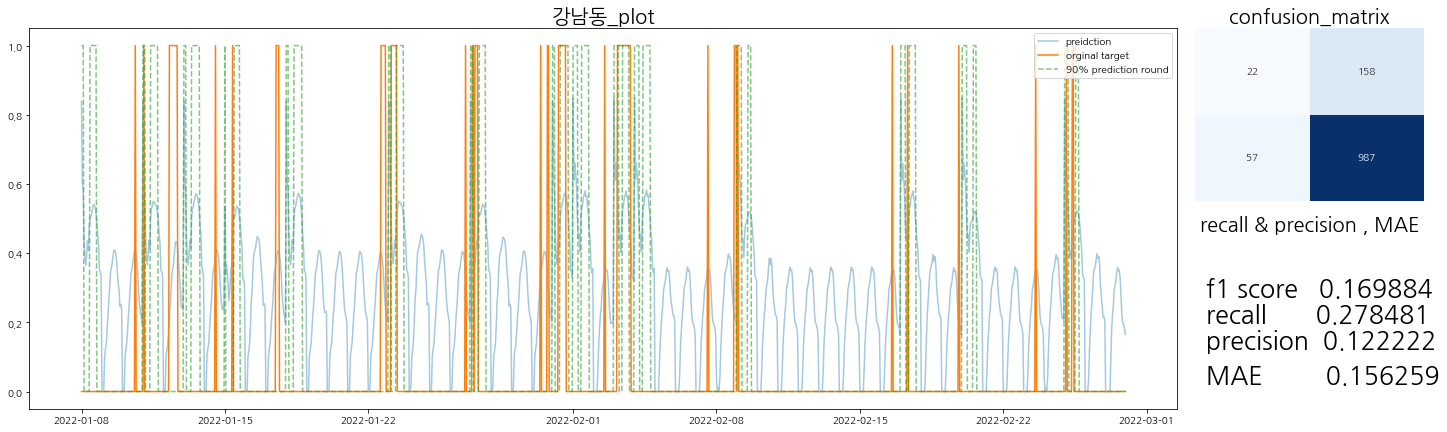

In [26]:
# ewma 적용
test_data = data_processing('test.csv' , 0.3)
confusion_matrix_plot(training, tft ,test_data, '강남동' , 'test')

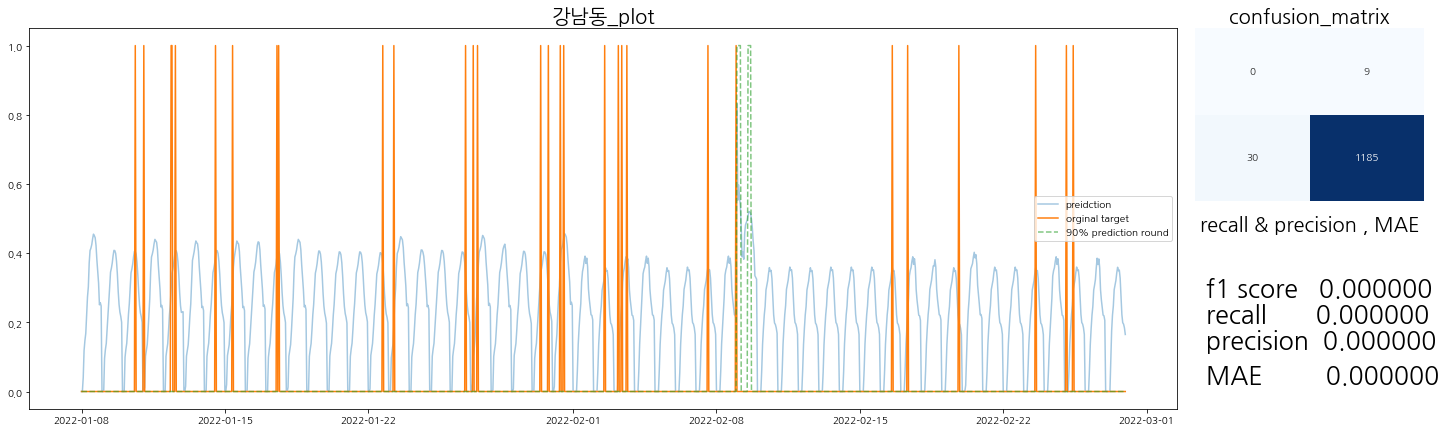

In [27]:
# ewma 적용 X
test_data = data_processing('test.csv' , 0)
confusion_matrix_plot(training, tft ,test_data, '강남동' , 'test')